In [1]:
# chain using langgraph 
# in this section we will see how we can build a simple chain using langgraph that uses 4 important concepts
# how to use chat messages as our graph state
# how to use chat models in graph nodes.
# how to bind tools to our LLM in chat models
# how to execute the tools call in our graph nodes

In [3]:
from dotenv import load_dotenv
load_dotenv()


import os
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

python-dotenv could not parse statement starting at line 8


In [4]:
# how to use chat messages as our grpah state
# messages
# we can use messages which can be used ot capture different roles within a conversation. langchain has various message types 
# including humman Message , AI Message , SystemMessage  and toolmessage
# these represent a message from the user, from cat model, for the chat model to instruct behavior, and from at tool call

# every message have these important components.

# content - content of the message
# name - Specify the name of author
# response_metadata - optinally , a dict of metadata (eg. often populated by model provider for AIMessage)

In [8]:
from langchain_core.messages import AIMessage,HumanMessage
from pprint import pprint

messages = [AIMessage(content = f"Please tell me how can I help", name="LLMModel")]
messages.append(HumanMessage(content=f"I want to learn coding", name = "Harshit"))

messages.append(AIMessage(content = f"which programing language you want to learn", name="LLMModel"))

messages.append(HumanMessage(content=f"I want to learn python programing language", name = "Harshit"))

for message in messages:
    message.pretty_print()

================================== Ai Message ==================================
Name: LLMModel

Please tell me how can I help
================================ Human Message =================================
Name: Harshit

I want to learn coding
================================== Ai Message ==================================
Name: LLMModel

which programing language you want to learn
================================ Human Message =================================
Name: Harshit

I want to learn python programing language


In [14]:
# chat models
# we can use the sequence of message as input with the catmodels using LLM's and OPENAI.



In [10]:
from langchain_groq import ChatGroq
llm = ChatGroq(model="qwen/qwen3-32b")

result = llm.invoke(messages)

In [11]:
result.response_metadata

{'token_usage': {'completion_tokens': 1179,
  'prompt_tokens': 56,
  'total_tokens': 1235,
  'completion_time': 2.63225594,
  'completion_tokens_details': None,
  'prompt_time': 0.002104769,
  'prompt_tokens_details': None,
  'queue_time': 0.05403189,
  'total_time': 2.634360709},
 'model_name': 'qwen/qwen3-32b',
 'system_fingerprint': 'fp_5cf921caa2',
 'service_tier': 'on_demand',
 'finish_reason': 'stop',
 'logprobs': None,
 'model_provider': 'groq'}

In [13]:
result.pretty_print()

================================== Ai Message ==================================

<think>
Okay, the user wants to learn Python. Let me start by breaking down what they need. First, they probably need a clear path with resources. I should mention the basics they should start with, like syntax and data types. Maybe suggest some beginner-friendly resources like "Python Crash Course" or online platforms like Codecademy.

They might also need to know about setting up their environment. I should include installing Python and an IDE like VS Code or PyCharm. Oh, and maybe mention Jupyter Notebook for interactive coding.

Practical projects are important. Suggesting small projects like a calculator or a to-do list can help them apply what they learn. As they progress, more complex projects like web scraping or data analysis could be next steps.

Community support is crucial. Maybe recommend joining forums like Reddit's r/learnpython or Stack Overflow. Also, GitHub for sharing code and collabora

In [15]:
# Tools
# Tools can be integrated with the LLM models to interact with external systems. External systems can be API's , third pary tools.
# whenever a query is asked the model can choose to call the tool and this query is based on the natural language input and this will return an output that matches the tool's schema

In [16]:
def add(a: int,b: int) -> int:
    """Add a and b
    Args : 
        a (int) : first int
        b (int): Second int

    Returns:
        int  
    """
    return a+b

In [17]:
llm

ChatGroq(output_version=None, profile={'max_input_tokens': 131072, 'max_output_tokens': 16384, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x0000017ACEA5F020>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000017ACEAA5520>, model_name='qwen/qwen3-32b', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [19]:
# binding tool with llm

llm_with_tools = llm.bind_tools([add])

tool_call =llm_with_tools.invoke([HumanMessage(content=f"what is 2 plus 2",name="Harshit")])

In [20]:
tool_call.tool_calls

[{'name': 'add',
  'args': {'a': 2, 'b': 2},
  'id': '57premadc',
  'type': 'tool_call'}]

In [21]:
# using message as state 

In [23]:
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage


class State(TypedDict):
    message:list[AnyMessage]

In [22]:
# reducers 

In [ ]:
from langgraph.graph.message import add_messages
from typing import Annotated
class State(TypedDict):
    messages:Annotated[list[AnyMessage],add_messages]

In [25]:
# Reducers with add_messages

In [26]:
initial_messages = [AIMessage(content = f"Please tell me how can I help", name="LLMModel")]
initial_messages.append(HumanMessage(content=f"I want to learn coding", name = "Harshit"))


In [27]:
initial_messages

[AIMessage(content='Please tell me how can I help', additional_kwargs={}, response_metadata={}, name='LLMModel', tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content='I want to learn coding', additional_kwargs={}, response_metadata={}, name='Harshit')]

In [28]:
ai_message = AIMessage(content = f"which programing language you want to learn", name="LLMModel")
ai_message


AIMessage(content='which programing language you want to learn', additional_kwargs={}, response_metadata={}, name='LLMModel', tool_calls=[], invalid_tool_calls=[])

In [30]:
# Reducers andd_messages is ot append instead of override
add_messages(initial_messages,ai_message)

[AIMessage(content='Please tell me how can I help', additional_kwargs={}, response_metadata={}, name='LLMModel', id='153e9f86-7ead-4738-951b-157e73596223', tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content='I want to learn coding', additional_kwargs={}, response_metadata={}, name='Harshit', id='f4912bfb-b77a-48fb-8241-ea1f1a404d13'),
 AIMessage(content='which programing language you want to learn', additional_kwargs={}, response_metadata={}, name='LLMModel', id='72797d1c-271c-4eaf-9f8d-1eddca573804', tool_calls=[], invalid_tool_calls=[])]

In [32]:
# chat bot node functionality
def llm_tool(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}




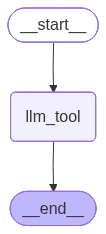

In [33]:
from IPython.display import Image,display
from langgraph.graph import StateGraph,START,END

builder = StateGraph(State)

builder.add_node("llm_tool",llm_tool)

builder.add_edge(START,"llm_tool")
builder.add_edge("llm_tool",END)

graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [34]:
# invocation

messages = graph.invoke({"messages":"what is 2 plus 2"})

In [37]:
for message in messages["messages"]:
    message.pretty_print()
    

================================ Human Message =================================

what is 2 plus 2
================================== Ai Message ==================================
Tool Calls:
  add (jmf7nbygd)
 Call ID: jmf7nbygd
  Args:
    a: 2
    b: 2
